## Optical Flow-based Tracking for Tracking Pharyngeal Pumping
Code adapted from [https://github.com/itberrios/CV_projects/tree/main]

In [2]:
### Imports
from library import *
!pip install openpyxl
plt.rcParams['axes.grid'] = False
VID_DIR = './pumpkin_videos/7-19-24' # Directory containing videos to be analyzed
VALIDATION = False # flag to determine if comparisons to manual will be made

---
### Unsupervised Motion Tracking

In [20]:
### Process all videos
# videos = ['eat2_fs_00001', 'eat2_fs_00002', 'eat2_fs_00003', 'eat2_fs_00004', 'eat2_fs_00005',
#           'eat2_ss_00001', 'eat2_ss_00002', 'eat2_ss_00003', 'eat2_ss_00004', 'eat2_ss_00005',
#           'eat2_ff_00001', 'eat2_ff_00002', 'eat2_ff_00003', 'eat2_ff_00004', 'eat2_ff_00005',
#           'eat2_sf_00001', 'eat2_sf_00002', 'eat2_sf_00003', 'eat2_sf_00004', 'eat2_sf_00005',
#           'n2_fs_00001',   'n2_fs_00002',   'n2_fs_00003',   'n2_fs_00004',   'n2_fs_00005',
#           'n2_ss_00001',   'n2_ss_00002',   'n2_ss_00003',   'n2_ss_00004',   'n2_ss_00005',
#           'n2_ff_00001',   'n2_ff_00002',   'n2_ff_00003',   'n2_ff_00004',   'n2_ff_00005',
#           'n2_sf_00001',   'n2_sf_00002',   'n2_sf_00003',   'n2_sf_00004',   'n2_sf_00005',
# ]
videos = ['n2_ss_00005']
all_motions, all_rates, all_peaks, all_troughs = [], [], [], []

### Run PumpKin on all videos to be analyzed
for video in videos:
    ### Load tracked grinder CoMs
    com_name  = VID_DIR + '/outputs/COMs/' + video + '_coms.csv'
    coms      = np.loadtxt(com_name)
    
    ### Set paths for saving (OPTIONAL) and for video
    full_name  = video + '_cropped.wmv'
    video_path = VID_DIR + '/cropped/' + full_name
    save_path  = VID_DIR + '/outputs/PumpKin/'
    vid        = cv2.VideoCapture(video_path)
    fps        = vid.get(cv2.CAP_PROP_FPS)

    ### Get raw grinder motion from video
    print('Processing ' + video)
    mags, angs = process_video(video_path, coms, save=True, save_path=save_path)
    
    ### Get filtered grinder motion
    print('Filtering grinder motion for ' + video)
    strain_name, cond_name = get_strain_cond(full_name)
    grinder_motion, fc = get_filtered_motion(strain_name, cond_name, mags, angs, fps)
    all_motions.append(grinder_motion)
    
    ### Get pumping rate (and pump times)
    print('Obtaining pumping rate for ' + video)
    pr_cont, pr_disc, peaks, troughs = get_pumping_rate(video_path, grinder_motion, fps, fc, save=True, save_path=save_path)
    all_rates.append(pr_cont)
    all_peaks.append(peaks)
    all_troughs.append(troughs)
    
print('Finished processing all videos.')

Processing n2_ss_00005
Labeled video saved to  ./pumpkin_videos/7-19-24/outputs/PumpKin/n2_ss_00005_PumpKin_slowed.avi
Filtering grinder motion for n2_ss_00005
Obtaining pumping rate for n2_ss_00005
Continuous pumping rate saved to ./pumpkin_videos/7-19-24/outputs/PumpKin/n2_ss_00005_PumpKin.csv
Pumping times saved to ./pumpkin_videos/7-19-24/outputs/PumpKin/n2_ss_00005_PumpKin_times.csv
Finished processing all videos.


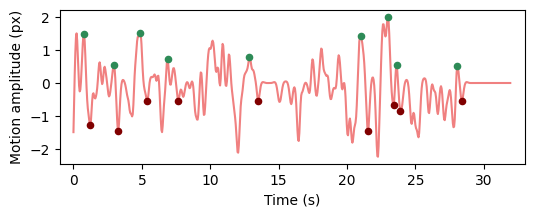

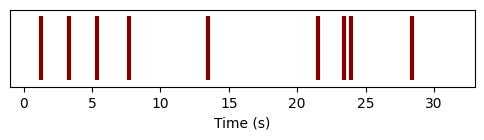

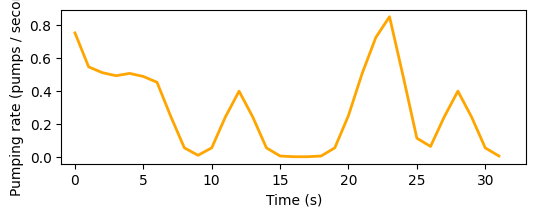

In [53]:
### Generate plots for all videos
for i, video in enumerate(videos):
    grinder_motion = all_motions[i]
    troughs        = all_troughs[i]
    peaks          = all_peaks[i]
    pk_pr_cont     = all_rates[i]

    ######################################################################
    ### Grinder motion with peaks and troughs labeled
    if VALIDATION:
        data_path = VID_DIR + '/Final_counts.xlsx'
        data      = pd.read_excel(data_path, sheet_name='Erin - full', header=None)
        col       = indices[index] # print the excel sheet in the cell below first to determine which row your data is on
        man_times = np.array(data.iloc[5:][col]).astype('float')
        man_times = man_times[~np.isnan(man_times)]
        man_pumps = np.ones(man_times.shape)

    dt     = 1/fps
    time_g = np.arange(0,(len(grinder_motion))*dt,dt)
    #save_path = VID_DIR + '/outputs/plots/' + videos[i] + '_PumpKin_signal.svg'
    save_path = VID_DIR + '/outputs/plots/example_motionamp.svg'
    plt.figure(figsize=(6,2))
    plt.plot(time_g,             grinder_motion, color='lightcoral', zorder=0)
    plt.scatter(time_g[troughs], grinder_motion[troughs], color='maroon',   s=20, zorder=1)  # Red dots for troughs
    plt.scatter(time_g[peaks],   grinder_motion[peaks],   color='seagreen', s=20, zorder=2)  # Green dots for peaks
    # Plot dotted vertical lines to represent manually labeled pumps
    if VALIDATION:
        for t in man_times:
            plt.axvline(x=t, color='royalblue', alpha=0.5, linestyle='--', label='Manual pumps' if t == man_times[0] else "")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlim([-1,33])
    plt.xlabel('Time (s)', fontsize=10)
    plt.ylabel('Motion amplitude (px)', fontsize=10)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    
    ######################################################################
    ### Pump raster plot
    save_path = VID_DIR + '/outputs/plots/example_raster.svg'
    plt.figure(figsize=(6,1))
    plt.eventplot(all_troughs[i]/fps, lw=3, linelengths=0.5, color='maroon')
    plt.tick_params(labelleft=False, left=False)
    plt.xlim([-1,33])
    plt.ylim([0.7,1.3])
    plt.xlabel('Time (s)', fontsize=10)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    ######################################################################
    ### Continuous pumping rate
    if VALIDATION:
        sigma     = 1
        bins      = make_bin_edges(fps,dt,coms.shape[0])
        pumps_per_bin, bin_edges = np.histogram(man_times*fps, bins=bins)

        # Convert bin counts to discrete pumping rate
        man_pr_disc = pumps_per_bin * bin_width/fps
        man_pr_cont = gaussian_filter1d(man_pr_disc, sigma, mode='nearest')

    #save_path = VID_DIR + '/outputs/plots/' + videos[i] + '_contpr.svg'
    save_path = VID_DIR + '/outputs/plots/example_contpr.svg'
    plt.figure(figsize=(6,2))
    if VALIDATION: plt.plot(man_pr_cont,color='royalblue',alpha=0.5,lw=2,label='Manual (mean = ' + str(np.round(np.mean(man_pr_cont),2)) + ')')
    plt.plot(pk_pr_cont,color='orange',lw=2,label='PumpKin (mean = ' + str(np.round(np.mean(pk_pr_cont),2)) + ')')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlim([-1,33])
    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("Pumping rate (pumps / second)", fontsize=10)
    #plt.legend()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

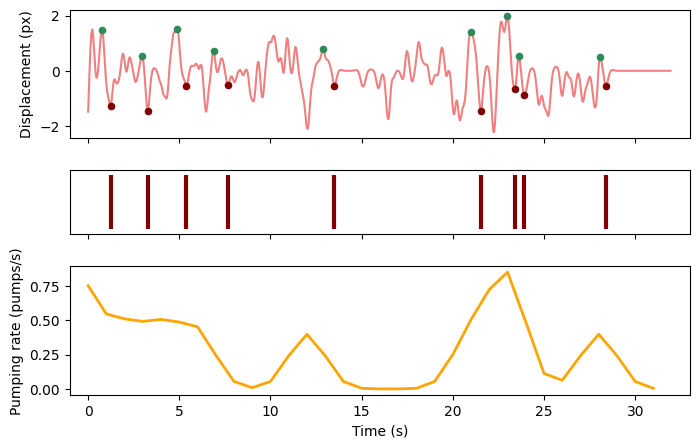

In [57]:
### Plot motion, raster, and rate all in same plot
for i, video in enumerate(videos):
    grinder_motion = all_motions[i]
    troughs        = all_troughs[i]
    peaks          = all_peaks[i]
    pk_pr_cont     = all_rates[i]

    if VALIDATION:
        data_path = VID_DIR + '/Final_counts.xlsx'
        data      = pd.read_excel(data_path, sheet_name='Erin - full', header=None)
        col       = indices[index]
        man_times = np.array(data.iloc[5:][col]).astype('float')
        man_times = man_times[~np.isnan(man_times)]
        man_pumps = np.ones(man_times.shape)

    dt     = 1 / fps
    time_g = np.arange(0, len(grinder_motion) * dt, dt)
    save_path = VID_DIR + '/outputs/plots/example_combined.svg'

    fig, axs = plt.subplots(3, 1, figsize=(8, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1, 2]})
    fig.subplots_adjust(hspace=0.3)

    ######################################################################
    # Subplot 1: Grinder motion with peaks and troughs
    axs[0].plot(time_g, grinder_motion, color='lightcoral', zorder=0)
    axs[0].scatter(time_g[troughs], grinder_motion[troughs], color='maroon', s=20, zorder=1)
    axs[0].scatter(time_g[peaks],   grinder_motion[peaks],   color='seagreen', s=20, zorder=2)
    if VALIDATION:
        for t in man_times:
            axs[0].axvline(x=t, color='royalblue', alpha=0.5, linestyle='--')
    axs[0].set_ylabel('Displacement (px)', fontsize=10)
    axs[0].tick_params(labelsize=10)
    axs[0].set_xlim([-1, 33])

    ######################################################################
    # Subplot 2: Pump raster plot
    axs[1].eventplot(all_troughs[i] / fps, lw=3, linelengths=0.5, color='maroon')
    axs[1].tick_params(labelleft=False, left=False, labelsize=10)
    axs[1].set_ylim([0.7, 1.3])

    ######################################################################
    # Subplot 3: Continuous pumping rate
    if VALIDATION:
        sigma = 1
        bins = make_bin_edges(fps, dt, coms.shape[0])
        pumps_per_bin, bin_edges = np.histogram(man_times * fps, bins=bins)
        man_pr_disc = pumps_per_bin * bin_width / fps
        man_pr_cont = gaussian_filter1d(man_pr_disc, sigma, mode='nearest')
        axs[2].plot(man_pr_cont, color='royalblue', alpha=0.5, lw=2,
                    label='Manual (mean = ' + str(np.round(np.mean(man_pr_cont), 2)) + ')')

    axs[2].plot(pk_pr_cont, color='orange', lw=2,
                label='PumpKin (mean = ' + str(np.round(np.mean(pk_pr_cont), 2)) + ')')
    axs[2].set_xlabel('Time (s)', fontsize=10)
    axs[2].set_ylabel('Pumping rate (pumps/s)', fontsize=10)
    axs[2].tick_params(labelsize=10)
    # axs[2].legend()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()